# Loan Default Risk Prediction — Initial Model Notebook
**Project:** An Interactive Predictive Diagnostic System for Loan Default Risk Prediction Among Underbanked Borrowers Utilizing XGBoost with Cost-Sensitive Class Weighting and a SHAP-Based Explanation Stability Audit

**Author:** Henriette Utatsineza

**Track:** ML Track — ALU Capstone

**Dataset:** Give Me Some Credit (Kaggle)

This notebook covers the *initial* software demonstration requirements:
1. Data visualization and data engineering
2. Model architecture (baseline + XGBoost with cost-sensitive weighting)
3. Initial performance metrics (PR-AUC, F1-score, ROC-AUC)
4. A first look at SHAP explanations (full stability audit comes in a later notebook)

**Everything in this notebook auto-saves to Google Drive** (models, plots, results) so nothing is lost between sessions.


## 1. Setup

In [4]:
!pip install xgboost shap scikit-learn pandas matplotlib seaborn joblib -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_recall_curve, auc, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import shap
import joblib
import os

np.random.seed(42)
sns.set_style("whitegrid")


## 1.1 Connect Google Drive

Run this cell and follow the popup to authorize access. If your session disconnects or you close
the tab, nothing is lost — just re-run from here and your saved files/models will still be in Drive.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# All outputs for this project go in one consistent folder
PROJECT_DIR = "/content/drive/MyDrive/loan-default-thesis"
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

for d in [PROJECT_DIR, MODELS_DIR, PLOTS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Saving everything to:", PROJECT_DIR)


Mounted at /content/drive
Saving everything to: /content/drive/MyDrive/loan-default-thesis


In [7]:
def save_fig(filename):
    """Save the current matplotlib figure to Drive before showing it."""
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print(f"Saved plot -> {path}")


## 2. Load Data

Upload `cs-training.csv` to this Colab session (folder icon on the left → upload).
If your download was a `.zip` file, unzip it first with the cell below (skip if you already have the plain CSV).

In [8]:
# Only needed if your Kaggle download came as a .zip — safe to skip otherwise
import zipfile
if os.path.exists("cs-training.csv.zip"):
    with zipfile.ZipFile("cs-training.csv.zip", "r") as z:
        z.extractall(".")
    print("Unzipped.")


Unzipped.


In [9]:
df = pd.read_csv("cs-training.csv", index_col=0)
print("Shape:", df.shape)

# Save a copy of the raw dataset to Drive too, so you always have it even if Colab disconnects
df.to_csv(os.path.join(RESULTS_DIR, "raw_data_snapshot.csv"))
df.head()


Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. Data Visualization and Data Engineering

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64
Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/01_class_distribution.png


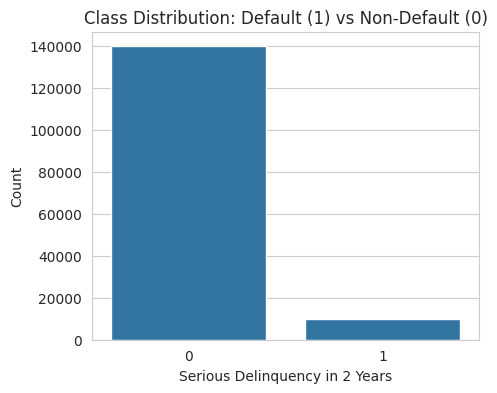

In [10]:
# Target variable distribution — this is the class imbalance problem (Sub-Problem 1)
target = "SeriousDlqin2yrs"
print(df[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x=target, data=df)
plt.title("Class Distribution: Default (1) vs Non-Default (0)")
plt.xlabel("Serious Delinquency in 2 Years")
plt.ylabel("Count")
save_fig("01_class_distribution.png")
plt.show()


MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64
Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/02_missing_values.png


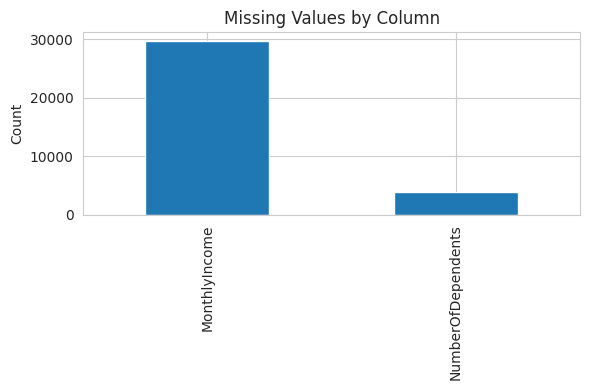

In [11]:
# Missing values check
missing = df.isnull().sum()
print(missing[missing > 0])

plt.figure(figsize=(6,4))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.tight_layout()
save_fig("02_missing_values.png")
plt.show()


Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/03_feature_distributions.png


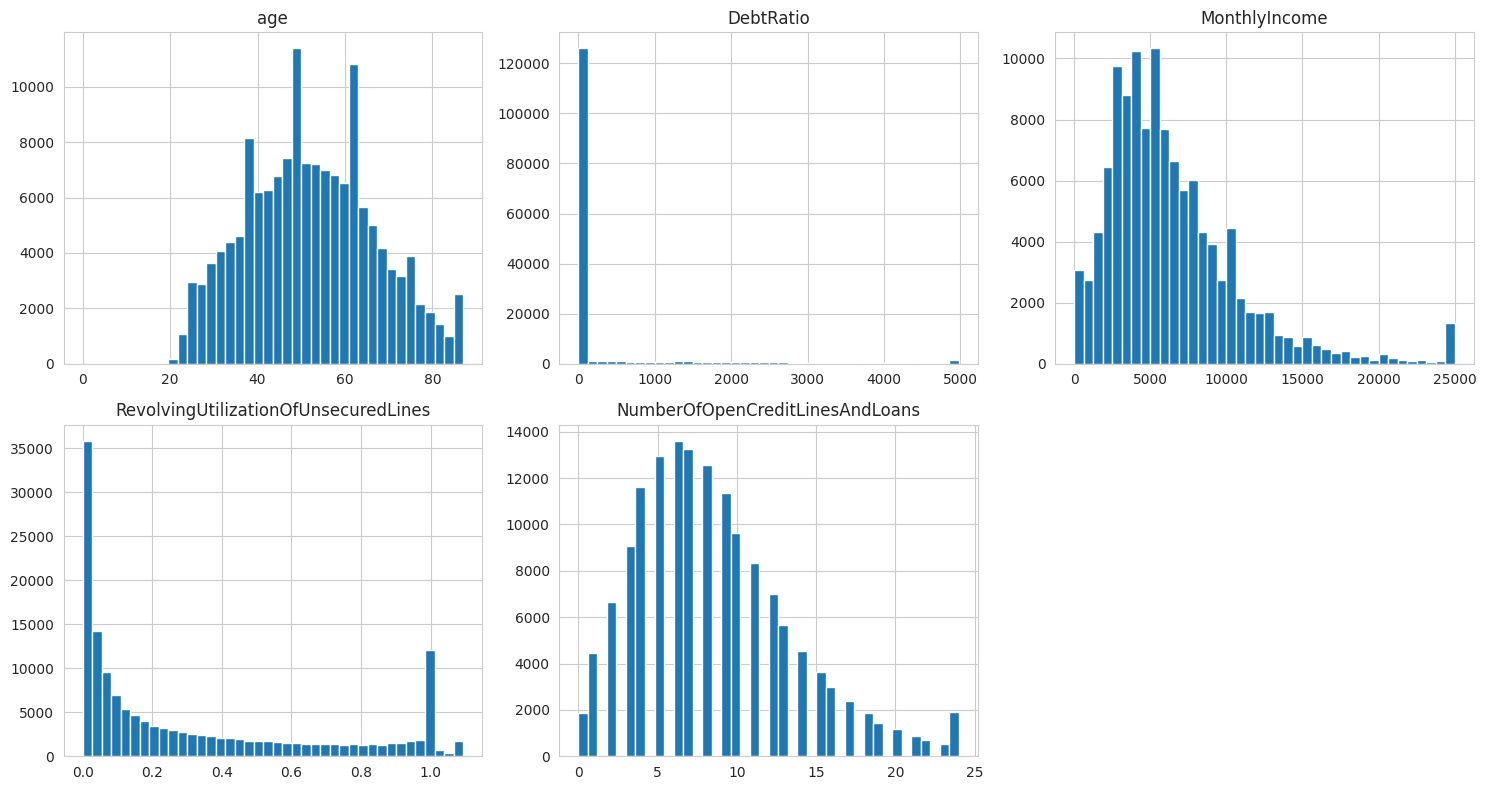

In [12]:
# Feature distributions
features_to_plot = ["age", "DebtRatio", "MonthlyIncome",
                     "RevolvingUtilizationOfUnsecuredLines", "NumberOfOpenCreditLinesAndLoans"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    # clip extreme outliers just for visualization
    data = df[col].clip(upper=df[col].quantile(0.99))
    axes[i].hist(data.dropna(), bins=40)
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
save_fig("03_feature_distributions.png")
plt.show()


Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/04_correlation_heatmap.png


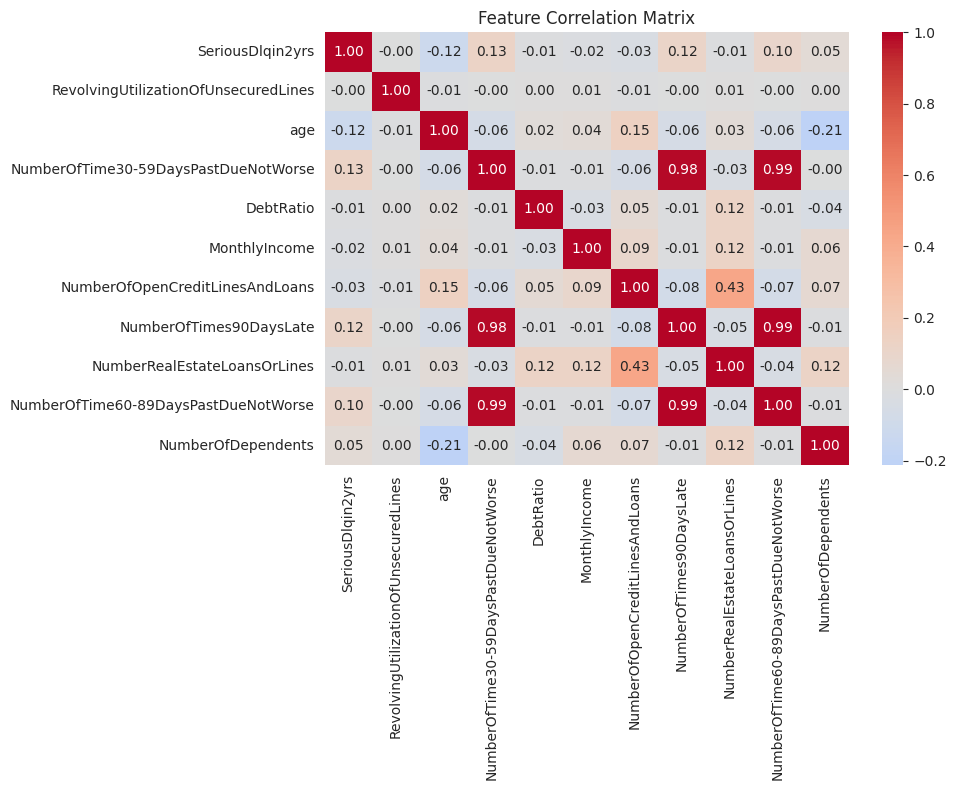

In [13]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
save_fig("04_correlation_heatmap.png")
plt.show()


## 4. Data Preprocessing

In [14]:
df_clean = df.copy()

# Median imputation for the two fields with missing values (per Chapter 3 methodology)
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].fillna(df_clean["MonthlyIncome"].median())
df_clean["NumberOfDependents"] = df_clean["NumberOfDependents"].fillna(df_clean["NumberOfDependents"].median())

assert df_clean.isnull().sum().sum() == 0, "There are still missing values!"
print("Missing values after imputation:", df_clean.isnull().sum().sum())

df_clean.to_csv(os.path.join(RESULTS_DIR, "cleaned_data.csv"))
print("Saved cleaned dataset to Drive.")


Missing values after imputation: 0
Saved cleaned dataset to Drive.


In [15]:
X = df_clean.drop(columns=[target])
y = df_clean[target]

# Stratified 80:20 split — preserves the ~6.7% default rate in both partitions (Section 3.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "| Default rate:", y_train.mean().round(4))
print("Test shape:", X_test.shape, "| Default rate:", y_test.mean().round(4))

# Save the split so it's identical every time you resume work (important for reproducibility)
joblib.dump((X_train, X_test, y_train, y_test), os.path.join(MODELS_DIR, "train_test_split.pkl"))


Train shape: (120000, 10) | Default rate: 0.0668
Test shape: (30000, 10) | Default rate: 0.0668


['/content/drive/MyDrive/loan-default-thesis/models/train_test_split.pkl']

## 5. Model Architecture

### 5.1 Baseline: Logistic Regression
Standard baseline used across the reviewed literature (Rai et al., 2024).

In [16]:
baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline.fit(X_train, y_train)

baseline_proba = baseline.predict_proba(X_test)[:, 1]

joblib.dump(baseline, os.path.join(MODELS_DIR, "baseline_logistic_regression.pkl"))
print("Saved baseline model to Drive.")


Saved baseline model to Drive.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5.2 Primary Model: XGBoost with Cost-Sensitive Class Weighting

`scale_pos_weight` is set to the inverse class ratio (~14), per Section 3.4.3 — this is the
**pure-data approach**: no SMOTE/ADASYN synthetic resampling is used anywhere in this pipeline.

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
)
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_model.save_model(os.path.join(MODELS_DIR, "xgboost_model_A.json"))
print("Saved XGBoost model to Drive.")


scale_pos_weight: 13.96
Saved XGBoost model to Drive.


## 6. Initial Performance Metrics

In [18]:
def evaluate(y_true, y_proba, model_name, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    roc_auc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"F1-score (default class): {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=["No Default", "Default"]))
    return {"model": model_name, "pr_auc": pr_auc, "roc_auc": roc_auc, "f1": f1}

results = []
results.append(evaluate(y_test, baseline_proba, "Logistic Regression (baseline)"))
results.append(evaluate(y_test, xgb_proba, "XGBoost (cost-sensitive weighting)"))

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RESULTS_DIR, "initial_performance_metrics.csv"), index=False)
print("Saved metrics to Drive.")
results_df


--- Logistic Regression (baseline) ---
PR-AUC:  0.3257
ROC-AUC: 0.8006
F1-score (default class): 0.2846
              precision    recall  f1-score   support

  No Default       0.97      0.78      0.87     27995
     Default       0.18      0.67      0.28      2005

    accuracy                           0.77     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.77      0.83     30000

--- XGBoost (cost-sensitive weighting) ---
PR-AUC:  0.4039
ROC-AUC: 0.8679
F1-score (default class): 0.3426
              precision    recall  f1-score   support

  No Default       0.98      0.80      0.88     27995
     Default       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000

Saved metrics to Drive.


,model,pr_auc,roc_auc,f1
0,Logistic Regression (baseline),0.325673,0.800556,0.284629
1,XGBoost (cost-sensitive weighting),0.403902,0.867877,0.342586


Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/05_model_comparison.png


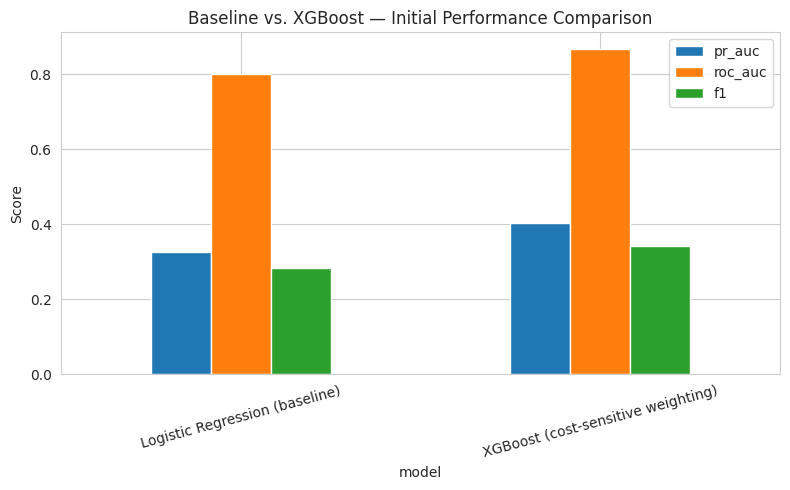

In [19]:
# Visual comparison
results_df.set_index("model")[["pr_auc", "roc_auc", "f1"]].plot(kind="bar", figsize=(8,5))
plt.title("Baseline vs. XGBoost — Initial Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
save_fig("05_model_comparison.png")
plt.show()


Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/06_confusion_matrix.png


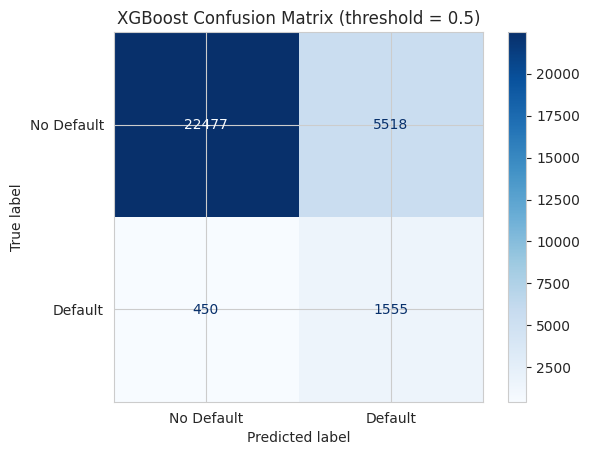

In [20]:
# Confusion matrix for the primary model
cm = confusion_matrix(y_test, (xgb_proba >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix (threshold = 0.5)")
save_fig("06_confusion_matrix.png")
plt.show()


## 7. Initial SHAP Explanation (Preview)

This is a first look at explainability — the full **explanation stability audit**
(comparing two matched-accuracy model variants) is the core research contribution
and will be built out in the next notebook.

/tmp/ipykernel_1357/3316264952.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.iloc[:500], show=False)


Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/07_shap_summary.png


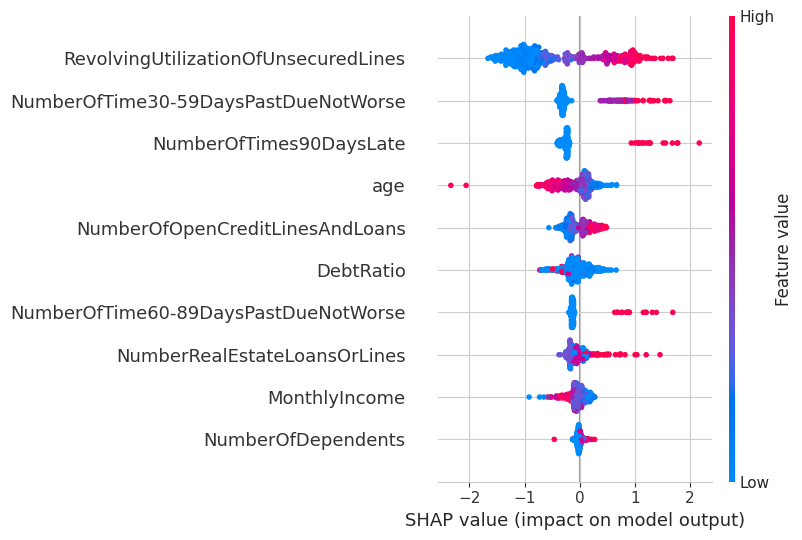

Saved SHAP explainer and values to Drive.


In [21]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:500])  # sample for speed in this initial demo

shap.summary_plot(shap_values, X_test.iloc[:500], show=False)
save_fig("07_shap_summary.png")
plt.show()

# Save the explainer + shap values too, so later notebooks (the full stability audit) can reuse them
joblib.dump(explainer, os.path.join(MODELS_DIR, "shap_explainer_model_A.pkl"))
np.save(os.path.join(RESULTS_DIR, "shap_values_model_A.npy"), shap_values)
print("Saved SHAP explainer and values to Drive.")


Borrower predicted default probability: 7.26%
Saved plot -> /content/drive/MyDrive/loan-default-thesis/plots/08_shap_single_borrower.png


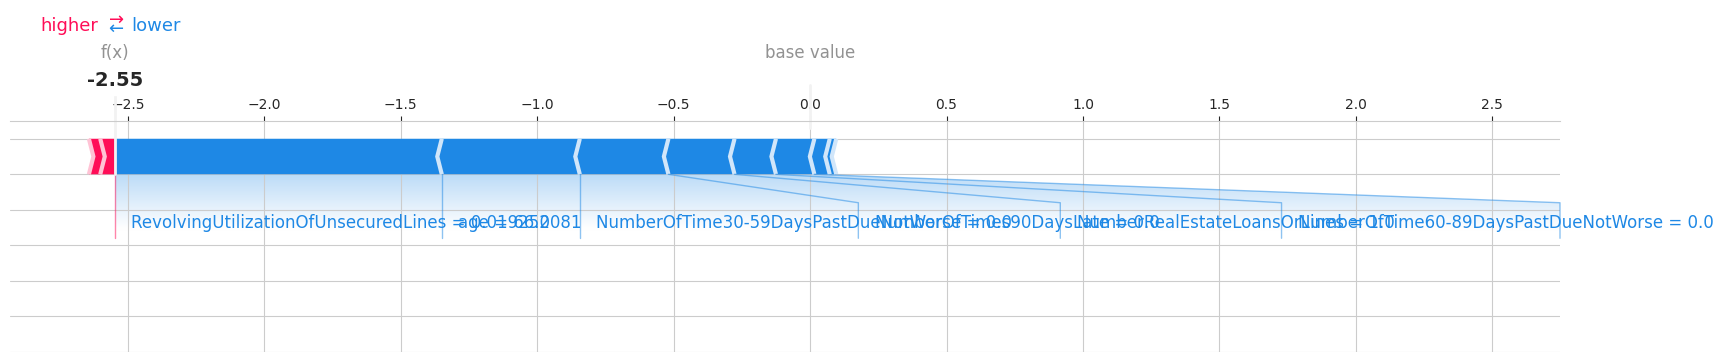

In [22]:
# Explanation for a single borrower — this is the kind of output the demo interface will show
sample_idx = 0
sample_borrower = X_test.iloc[[sample_idx]]
sample_proba = xgb_model.predict_proba(sample_borrower)[0, 1]

print(f"Borrower predicted default probability: {sample_proba:.2%}")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False,
)
save_fig("08_shap_single_borrower.png")
plt.show()


## 8. Save a Full Session Summary

One consolidated file confirming what was produced this session — useful for your README and for
picking up exactly where you left off next time.

In [23]:
summary = f"""
Session summary — {pd.Timestamp.now()}

Dataset: {df.shape[0]} rows, {df.shape[1]} columns
Train/test split: {X_train.shape[0]} / {X_test.shape[0]} (stratified, 80:20)

Models saved:
- {MODELS_DIR}/baseline_logistic_regression.pkl
- {MODELS_DIR}/xgboost_model_A.json
- {MODELS_DIR}/shap_explainer_model_A.pkl

Results saved:
- {RESULTS_DIR}/initial_performance_metrics.csv
- {RESULTS_DIR}/cleaned_data.csv
- {RESULTS_DIR}/shap_values_model_A.npy

Plots saved: {PLOTS_DIR}/ (8 PNG files)

Performance:
{results_df.to_string(index=False)}
"""

with open(os.path.join(PROJECT_DIR, "session_summary.txt"), "w") as f:
    f.write(summary)

print(summary)
print("Everything is safely stored in Google Drive at:", PROJECT_DIR)



Session summary — 2026-09-29 02:03:51.045445

Dataset: 150000 rows, 11 columns
Train/test split: 120000 / 30000 (stratified, 80:20)

Models saved:
- /content/drive/MyDrive/loan-default-thesis/models/baseline_logistic_regression.pkl
- /content/drive/MyDrive/loan-default-thesis/models/xgboost_model_A.json
- /content/drive/MyDrive/loan-default-thesis/models/shap_explainer_model_A.pkl

Results saved:
- /content/drive/MyDrive/loan-default-thesis/results/initial_performance_metrics.csv
- /content/drive/MyDrive/loan-default-thesis/results/cleaned_data.csv
- /content/drive/MyDrive/loan-default-thesis/results/shap_values_model_A.npy

Plots saved: /content/drive/MyDrive/loan-default-thesis/plots/ (8 PNG files)

Performance:
                             model   pr_auc  roc_auc       f1
    Logistic Regression (baseline) 0.325673 0.800556 0.284629
XGBoost (cost-sensitive weighting) 0.403902 0.867877 0.342586

Everything is safely stored in Google Drive at: /content/drive/MyDrive/loan-default-thes

## 9. Next Steps (Future Notebooks)
- Train Model B (second XGBoost variant, different seed/depth) matched on accuracy to Model A
- Run the SHAP Stability Audit: Spearman's Rank Correlation + Top-Feature Jaccard Index across a
  stratified 300-borrower sample (oversampling borderline 0.4–0.6 probability cases), per Section 3.2
- Build the lightweight local demo interface (Streamlit) for the deployment mockup
